[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skyexry/urban-mobility-forecast/blob/main/notebooks/11_train_eval.ipynb)

# 11 — Final Training & Evaluation

Clean final notebook. All 5 models on 100-station CitiBike demand forecasting.

**Changes from 07 (best baseline):**
- STGNN loss: `log_cosh` → **`asymmetric_log_cosh` (α=2.0)** — penalizes under-prediction 2× to improve peak tracking
- STGNN patience: 10 → 20
- Records: loss function, best val MAE, test MAE/RMSE, peak/off-peak MAE, early-stop epoch

**Settings:**
- `INPUT_WINDOW = 168` (1 week), `OUTPUT_WINDOW = 72`, `BATCH_SIZE = 16`
- STGNN: `hidden_channels=32, tcn_channels=64, use_transformer_decoder=True, decoder_layers=1`

## Setup

In [21]:
import os
if os.path.exists('/root/urban-mobility-forecast'):
    BASE_DIR = '/root/urban-mobility-forecast'
    DATA_DIR = '/root/urban-mobility-forecast/data'
else:
    BASE_DIR = '/content/urban-mobility-forecast'
    DATA_DIR = '/content/drive/MyDrive/citibike'
print(f'BASE_DIR: {BASE_DIR}')
print(f'DATA_DIR: {DATA_DIR}')

BASE_DIR: /root/urban-mobility-forecast
DATA_DIR: /root/urban-mobility-forecast/data


In [22]:
!git clone https://github.com/skyexry/urban-mobility-forecast.git 2>/dev/null || git -C urban-mobility-forecast pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.91 KiB | 652.00 KiB/s, done.
From https://github.com/skyexry/urban-mobility-forecast
   65901ee..96bef50  main       -> origin/main
Updating 65901ee..96bef50
Fast-forward
 notebooks/11_train_eval.ipynb | 147 +++++++++---------------------------------
 1 file changed, 30 insertions(+), 117 deletions(-)


In [23]:
import sys
if BASE_DIR == '/content/urban-mobility-forecast':
    from google.colab import drive
    drive.mount('/content/drive')
!pip install torch-geometric -q
sys.path.append(BASE_DIR)

In [24]:
import importlib, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import joblib, warnings
warnings.filterwarnings('ignore')

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

features_mod = load_module('features', f'{BASE_DIR}/preprocessing/features.py')
from model.stgnn import STGNN
from model.tcn import TCNBlock

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load Data

In [25]:
df       = pd.read_parquet(f'{DATA_DIR}/hourly_demand_filtered.parquet')
stations = pd.read_parquet(f'{DATA_DIR}/stations_final.parquet')
df['hour'] = pd.to_datetime(df['hour'])

edge_index  = torch.tensor(np.load(f'{DATA_DIR}/edge_index.npy'),  dtype=torch.long).to(DEVICE)
edge_weight = torch.tensor(np.load(f'{DATA_DIR}/edge_weight.npy'), dtype=torch.float).to(DEVICE)

print(f'Stations   : {df["start_station_id"].nunique()}')
print(f'Date range : {df["hour"].min()} → {df["hour"].max()}')
print(f'edge_index : {edge_index.shape}')

Stations   : 100
Date range : 2024-01-01 00:00:00 → 2025-12-31 23:00:00
edge_index : torch.Size([2, 656])


## 2. Build Demand Matrix & Time Features

In [26]:
station_ids = stations['start_station_id'].tolist()
demand_matrix, hours = features_mod.build_demand_matrix(df, station_ids)
time_feats = features_mod.build_time_features(pd.Series(hours))
print(f'demand_matrix : {demand_matrix.shape}')
print(f'time_features : {time_feats.shape}')

demand_matrix : (16808, 100)
time_features : (16808, 6)


In [27]:
print('Fetching weather data from Open-Meteo (NYC 2024–2025)...')
weather_df  = features_mod.fetch_weather_data('2024-01-01', '2025-12-31')
weather_raw = features_mod.build_weather_features(weather_df, hours)
print(f'weather_raw : {weather_raw.shape}  (T x 9)')

Fetching weather data from Open-Meteo (NYC 2024–2025)...
weather_raw : (16808, 9)  (T x 9)


## 3. Train / Val / Test Split

In [28]:
T      = demand_matrix.shape[0]
split1 = int(T * 0.70)
split2 = int(T * 0.85)

train_demand = demand_matrix[:split1]
val_demand   = demand_matrix[split1:split2]
test_demand  = demand_matrix[split2:]

train_time = time_feats[:split1]
val_time   = time_feats[split1:split2]
test_time  = time_feats[split2:]

normalized_train, scaler = features_mod.normalize_demand(train_demand)
normalized_val  = scaler.transform(np.log1p(val_demand).reshape(-1,1)).reshape(val_demand.shape)
normalized_test = scaler.transform(np.log1p(test_demand).reshape(-1,1)).reshape(test_demand.shape)
joblib.dump(scaler, f'{DATA_DIR}/scaler.pkl')

train_weather_raw = weather_raw[:split1]
val_weather_raw   = weather_raw[split1:split2]
test_weather_raw  = weather_raw[split2:]
norm_train_w, weather_scaler = features_mod.normalize_weather_features(train_weather_raw)
norm_val_w,   _              = features_mod.normalize_weather_features(val_weather_raw,  weather_scaler)
norm_test_w,  _              = features_mod.normalize_weather_features(test_weather_raw, weather_scaler)
joblib.dump(weather_scaler, f'{DATA_DIR}/weather_scaler.pkl')

print(f'Train: {train_demand.shape[0]} steps ({train_demand.shape[0]/24:.0f} days)')
print(f'Val  : {val_demand.shape[0]} steps ({val_demand.shape[0]/24:.0f} days)')
print(f'Test : {test_demand.shape[0]} steps ({test_demand.shape[0]/24:.0f} days)')

Train: 11765 steps (490 days)
Val  : 2521 steps (105 days)
Test : 2522 steps (105 days)


## 4. Sliding Windows & DataLoaders

In [29]:
INPUT_WINDOW  = 168
OUTPUT_WINDOW = 72
BATCH_SIZE    = 16

x_demand_train, x_time_train, y_train = features_mod.build_sliding_windows(normalized_train, train_time, INPUT_WINDOW, OUTPUT_WINDOW)
x_demand_val,   x_time_val,   y_val   = features_mod.build_sliding_windows(normalized_val,   val_time,   INPUT_WINDOW, OUTPUT_WINDOW)
x_demand_test,  x_time_test,  y_test  = features_mod.build_sliding_windows(normalized_test,  test_time,  INPUT_WINDOW, OUTPUT_WINDOW)

x_d_tr_w, x_t_tr_w, x_w_tr, y_tr_w = features_mod.build_sliding_windows(normalized_train, train_time, INPUT_WINDOW, OUTPUT_WINDOW, norm_train_w)
x_d_va_w, x_t_va_w, x_w_va, y_va_w = features_mod.build_sliding_windows(normalized_val,   val_time,   INPUT_WINDOW, OUTPUT_WINDOW, norm_val_w)
x_d_te_w, x_t_te_w, x_w_te, y_te_w = features_mod.build_sliding_windows(normalized_test,  test_time,  INPUT_WINDOW, OUTPUT_WINDOW, norm_test_w)

class CitiBikeDataset(Dataset):
    def __init__(self, x_demand, x_time, y):
        self.x_demand = torch.tensor(x_demand, dtype=torch.float32)
        self.x_time   = torch.tensor(x_time,   dtype=torch.float32)
        self.y        = torch.tensor(y,         dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x_demand[i], self.x_time[i], self.y[i]

class CitiBikeWeatherDataset(Dataset):
    def __init__(self, x_d, x_t, x_w, y):
        self.x_d = torch.tensor(x_d, dtype=torch.float32)
        self.x_t = torch.tensor(x_t, dtype=torch.float32)
        self.x_w = torch.tensor(x_w, dtype=torch.float32)
        self.y   = torch.tensor(y,   dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x_d[i], self.x_t[i], self.x_w[i], self.y[i]

train_loader   = DataLoader(CitiBikeDataset(x_demand_train, x_time_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader     = DataLoader(CitiBikeDataset(x_demand_val,   x_time_val,   y_val),   batch_size=BATCH_SIZE)
test_loader    = DataLoader(CitiBikeDataset(x_demand_test,  x_time_test,  y_test),  batch_size=BATCH_SIZE)
train_w_loader = DataLoader(CitiBikeWeatherDataset(x_d_tr_w, x_t_tr_w, x_w_tr, y_tr_w), batch_size=BATCH_SIZE, shuffle=True)
val_w_loader   = DataLoader(CitiBikeWeatherDataset(x_d_va_w, x_t_va_w, x_w_va, y_va_w), batch_size=BATCH_SIZE)
test_w_loader  = DataLoader(CitiBikeWeatherDataset(x_d_te_w, x_t_te_w, x_w_te, y_te_w), batch_size=BATCH_SIZE)
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')

Samples  : 11526
x_demand : (11526, 100, 168, 1)
x_time   : (11526, 168, 6)
y        : (11526, 100, 72, 1)
Samples  : 2282
x_demand : (2282, 100, 168, 1)
x_time   : (2282, 168, 6)
y        : (2282, 100, 72, 1)
Samples  : 2283
x_demand : (2283, 100, 168, 1)
x_time   : (2283, 168, 6)
y        : (2283, 100, 72, 1)
Samples  : 11526
x_demand : (11526, 100, 168, 1)
x_time   : (11526, 168, 6)
y        : (11526, 100, 72, 1)
x_weather: (11526, 168, 9)
Samples  : 2282
x_demand : (2282, 100, 168, 1)
x_time   : (2282, 168, 6)
y        : (2282, 100, 72, 1)
x_weather: (2282, 168, 9)
Samples  : 2283
x_demand : (2283, 100, 168, 1)
x_time   : (2283, 168, 6)
y        : (2283, 100, 72, 1)
x_weather: (2283, 168, 9)
Train: 721 batches | Val: 143 | Test: 143


## 5. Training Utilities

In [31]:
def log_cosh_loss(pred, target):
    return torch.log(torch.cosh(pred - target)).mean()

def asymmetric_log_cosh_loss(pred, target, alpha=2.0):
    """Log-cosh loss with asymmetric weighting: under-prediction penalized alpha× more."""
    residual = target - pred
    weight   = torch.where(residual > 0,
                           alpha * torch.ones_like(residual),
                           torch.ones_like(residual))
    return (weight * torch.log(torch.cosh(pred - target))).mean()

def train_epoch(model, loader, optimizer, loss_fn, forward_fn, epoch):
    model.train()
    total_loss, total_mae = 0, 0
    pbar = tqdm(loader, desc=f'Epoch {epoch:3d} [train]', leave=False)
    for x_d, x_t, y in pbar:
        x_d, x_t, y = x_d.to(DEVICE), x_t.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = forward_fn(model, x_d, x_t)
        loss = loss_fn(pred, y.squeeze(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_mae  += (pred - y.squeeze(-1)).abs().mean().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    n = len(loader)
    return total_loss / n, total_mae / n

def eval_epoch(model, loader, forward_fn):
    model.eval()
    mae_total, mse_total = 0, 0
    pbar = tqdm(loader, desc='              [val]', leave=False)
    with torch.no_grad():
        for x_d, x_t, y in pbar:
            x_d, x_t, y = x_d.to(DEVICE), x_t.to(DEVICE), y.to(DEVICE)
            diff = forward_fn(model, x_d, x_t) - y.squeeze(-1)
            mae_total += diff.abs().mean().item()
            mse_total += (diff ** 2).mean().item()
            pbar.set_postfix({'val_mae': f'{mae_total / (pbar.n + 1):.4f}'})
    n = len(loader)
    return mae_total / n, (mse_total / n) ** 0.5

def run_training(model, train_loader, val_loader, forward_fn,
                 loss_fn=None, lr=1e-3, epochs=100, patience=20, save_path=None):
    if loss_fn is None:
        loss_fn = log_cosh_loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    best_val, wait, history = float('inf'), 0, []
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_mae     = train_epoch(model, train_loader, optimizer, loss_fn, forward_fn, epoch)
        vl_mae, vl_rmse     = eval_epoch(model, val_loader, forward_fn)
        history.append((tr_loss, tr_mae, vl_mae, vl_rmse))
        scheduler.step(vl_mae)
        lr_now = optimizer.param_groups[0]['lr']

        print(f'Epoch {epoch:3d} | train loss {tr_loss:.4f} | train MAE {tr_mae:.4f} | val MAE {vl_mae:.4f} | val RMSE {vl_rmse:.4f} | best {best_val:.4f} | patience {wait}/{patience} | lr {lr_now:.2e}')

        if vl_mae < best_val:
            best_val, wait, best_epoch = vl_mae, 0, epoch
            if save_path:
                torch.save(model.state_dict(), save_path)
        else:
            wait += 1
            if wait >= patience:
                print(f'→ Early stop @ epoch {epoch}  (best epoch {best_epoch})')
                break

    return history, best_epoch

def compute_metrics(y_true, y_pred, scaler):
    y_true = features_mod.inverse_transform_demand(y_true, scaler)
    y_pred = features_mod.inverse_transform_demand(y_pred, scaler)
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return dict(MAE=mae, RMSE=rmse)

def get_predictions(model, loader, forward_fn):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_d, x_t, y in tqdm(loader, desc='Predicting', leave=False):
            x_d, x_t = x_d.to(DEVICE), x_t.to(DEVICE)
            preds.append(forward_fn(model, x_d, x_t).cpu().numpy())
            trues.append(y.squeeze(-1).numpy())
    return np.concatenate(preds), np.concatenate(trues)

def peak_offpeak_mae(preds_r, trues_r, hours_hod, split2):
    n_samples = preds_r.shape[0]
    i_idx     = np.arange(n_samples)[:, None]
    t_idx     = np.arange(OUTPUT_WINDOW)[None, :]
    step_hod  = hours_hod[split2 + INPUT_WINDOW + i_idx + t_idx]
    err_step  = np.abs(preds_r - trues_r).mean(axis=1)
    peak      = [7, 8, 9, 17, 18, 19]
    peak_mae    = np.mean([err_step[step_hod == h].mean() for h in peak])
    offpeak_mae = np.mean([err_step[step_hod == h].mean() for h in range(24) if h not in peak])
    return peak_mae, offpeak_mae

print('Training utilities loaded.')

Training utilities loaded.


## 6. Baseline — Historical Average

In [32]:
N         = normalized_train.shape[1]
T_train   = normalized_train.shape[0]
hod_train = np.array([h.hour for h in hours[:T_train]])
hours_hod = hours.hour.values

ha_pred = np.zeros((24, N))
for h in range(24):
    mask = hod_train == h
    ha_pred[h] = normalized_train[mask].mean(axis=0)

hod_test = np.array([h.hour for h in hours[split2:]])
y_true_ha, y_pred_ha = [], []
for i in range(INPUT_WINDOW, len(normalized_test) - OUTPUT_WINDOW + 1):
    y_true_ha.append(normalized_test[i:i+OUTPUT_WINDOW])
    y_pred_ha.append(ha_pred[hod_test[i:i+OUTPUT_WINDOW]])

y_true_ha = np.stack(y_true_ha)
y_pred_ha = np.stack(y_pred_ha)
metrics_ha = compute_metrics(y_true_ha, y_pred_ha, scaler)
print('Historical Average:', {k: f"{v:.4f}" for k, v in metrics_ha.items()})

Historical Average: {'MAE': '13.1798', 'RMSE': '21.1992'}


## 7. LSTM

In [33]:
class LSTMModel(nn.Module):
    def __init__(self, num_nodes, input_window, output_window, hidden=64, num_layers=2):
        super().__init__()
        self.num_nodes     = num_nodes
        self.output_window = output_window
        self.lstm = nn.LSTM(1, hidden, num_layers, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden, output_window)
    def forward(self, x_demand, x_time=None):
        b, N, T, _ = x_demand.shape
        out, _ = self.lstm(x_demand.reshape(b * N, T, 1))
        return self.fc(out[:, -1, :]).reshape(b, N, self.output_window)

In [34]:
torch.manual_seed(42); np.random.seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed(42)

lstm_model   = LSTMModel(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW).to(DEVICE)
lstm_forward = lambda model, x_d, x_t: model(x_d, x_t)
print(f'LSTM parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')

history_lstm, lstm_best_epoch = run_training(
    lstm_model, train_loader, val_loader, lstm_forward,
    loss_fn=log_cosh_loss, patience=10,
    save_path=f'{DATA_DIR}/lstm_11_best.pth'
)

LSTM parameters: 55,112


Epoch   1 | train loss 0.0421 | train MAE 0.2297 | val MAE 0.2179 | val RMSE 0.2806 | best inf | patience 0/10 | lr 1.00e-03


Epoch   2 | train loss 0.0306 | train MAE 0.1931 | val MAE 0.2096 | val RMSE 0.2716 | best 0.2179 | patience 0/10 | lr 1.00e-03


Epoch   3 | train loss 0.0295 | train MAE 0.1889 | val MAE 0.2026 | val RMSE 0.2657 | best 0.2096 | patience 0/10 | lr 1.00e-03


Epoch   4 | train loss 0.0287 | train MAE 0.1857 | val MAE 0.2012 | val RMSE 0.2622 | best 0.2026 | patience 0/10 | lr 1.00e-03


...

Epoch  40 | train loss 0.0207 | train MAE 0.1536 | val MAE 0.1699 | val RMSE 0.2308 | best 0.1692 | patience 5/10 | lr 2.50e-04


Epoch  41 | train loss 0.0205 | train MAE 0.1526 | val MAE 0.1694 | val RMSE 0.2300 | best 0.1692 | patience 6/10 | lr 2.50e-04


Epoch  42 | train loss 0.0205 | train MAE 0.1525 | val MAE 0.1694 | val RMSE 0.2297 | best 0.1692 | patience 7/10 | lr 2.50e-04


Epoch  43 | train loss 0.0204 | train MAE 0.1524 | val MAE 0.1699 | val RMSE 0.2302 | best 0.1692 | patience 8/10 | lr 2.50e-04


Epoch  44 | train loss 0.0204 | train MAE 0.1523 | val MAE 0.1698 | val RMSE 0.2295 | best 0.1692 | patience 9/10 | lr 2.50e-04
→ Early stop @ epoch 44  (best epoch 34)


In [35]:
lstm_model.load_state_dict(torch.load(f'{DATA_DIR}/lstm_11_best.pth', map_location=DEVICE))
preds_lstm, trues_lstm = get_predictions(lstm_model, test_loader, lstm_forward)
metrics_lstm = compute_metrics(trues_lstm, preds_lstm, scaler)
preds_lstm_r = features_mod.inverse_transform_demand(preds_lstm, scaler)
trues_lstm_r = features_mod.inverse_transform_demand(trues_lstm, scaler)
lstm_peak, lstm_offpeak = peak_offpeak_mae(preds_lstm_r, trues_lstm_r, hours_hod, split2)
print('LSTM:', {k: f"{v:.4f}" for k, v in metrics_lstm.items()})
print(f'  Peak MAE: {lstm_peak:.2f} | Off-peak MAE: {lstm_offpeak:.2f} | Best epoch: {lstm_best_epoch}')

LSTM: {'MAE': '8.0241', 'RMSE': '13.0856'}
  Peak MAE: 12.58 | Off-peak MAE: 6.51 | Best epoch: 34


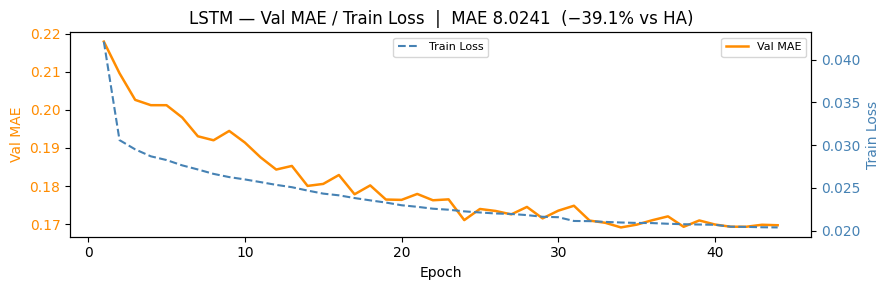

In [36]:
# LSTM — Loss curve + improvement
fig, ax = plt.subplots(figsize=(9, 3))
ep = range(1, len(history_lstm) + 1)
ax2 = ax.twinx()
ax.plot(ep, [h[2] for h in history_lstm], color='darkorange', linewidth=1.8, label='Val MAE')
ax2.plot(ep, [h[0] for h in history_lstm], color='steelblue', linestyle='--', linewidth=1.5, label='Train Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MAE', color='darkorange')
ax2.set_ylabel('Train Loss', color='steelblue')
ax.tick_params(axis='y', labelcolor='darkorange')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax.legend(loc='upper right', fontsize=8); ax2.legend(loc='upper center', fontsize=8)
pct = (metrics_ha['MAE'] - metrics_lstm['MAE']) / metrics_ha['MAE'] * 100
ax.set_title(f'LSTM — Val MAE / Train Loss  |  MAE {metrics_lstm["MAE"]:.4f}  (−{pct:.1f}% vs HA)')
plt.tight_layout(); plt.show()

## 8. TCN-only

In [37]:
class TCNOnlyModel(nn.Module):
    def __init__(self, num_nodes, input_window, output_window,
                 tcn_channels=64, time_channels=6, num_layers=4):
        super().__init__()
        self.num_nodes     = num_nodes
        self.output_window = output_window
        self.demand_tcn = TCNBlock(in_channels=1,             out_channels=tcn_channels, num_layers=num_layers)
        self.time_tcn   = TCNBlock(in_channels=time_channels, out_channels=tcn_channels, num_layers=num_layers)
        self.fc = nn.Linear(tcn_channels * 2, output_window)
    def forward(self, x_demand, x_time):
        b, N, T, _ = x_demand.shape
        d_out = self.demand_tcn(x_demand.reshape(b * N, T, 1).permute(0, 2, 1))[:, :, -1]
        t_out = self.time_tcn(x_time.permute(0, 2, 1))[:, :, -1].unsqueeze(1).expand(-1, N, -1).reshape(b * N, -1)
        return self.fc(torch.cat([d_out, t_out], dim=-1)).reshape(b, N, self.output_window)

In [38]:
torch.manual_seed(42); np.random.seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed(42)

tcn_model   = TCNOnlyModel(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW).to(DEVICE)
tcn_forward = lambda model, x_d, x_t: model(x_d, x_t)
print(f'TCN-only parameters: {sum(p.numel() for p in tcn_model.parameters()):,}')

history_tcn, tcn_best_epoch = run_training(
    tcn_model, train_loader, val_loader, tcn_forward,
    loss_fn=log_cosh_loss, patience=10,
    save_path=f'{DATA_DIR}/tcn_11_best.pth'
)

TCN-only parameters: 187,336


Epoch   1 | train loss 0.0478 | train MAE 0.2413 | val MAE 0.1935 | val RMSE 0.2538 | best inf | patience 0/10 | lr 1.00e-03


Epoch   2 | train loss 0.0283 | train MAE 0.1857 | val MAE 0.1886 | val RMSE 0.2457 | best 0.1935 | patience 0/10 | lr 1.00e-03


Epoch   3 | train loss 0.0262 | train MAE 0.1775 | val MAE 0.1846 | val RMSE 0.2409 | best 0.1886 | patience 0/10 | lr 1.00e-03


Epoch   4 | train loss 0.0252 | train MAE 0.1734 | val MAE 0.1850 | val RMSE 0.2404 | best 0.1846 | patience 0/10 | lr 1.00e-03


...

Epoch  41 | train loss 0.0217 | train MAE 0.1591 | val MAE 0.1716 | val RMSE 0.2281 | best 0.1693 | patience 5/10 | lr 1.25e-04


Epoch  42 | train loss 0.0217 | train MAE 0.1587 | val MAE 0.1723 | val RMSE 0.2283 | best 0.1693 | patience 6/10 | lr 1.25e-04


Epoch  43 | train loss 0.0216 | train MAE 0.1586 | val MAE 0.1723 | val RMSE 0.2284 | best 0.1693 | patience 7/10 | lr 1.25e-04


Epoch  44 | train loss 0.0217 | train MAE 0.1587 | val MAE 0.1727 | val RMSE 0.2285 | best 0.1693 | patience 8/10 | lr 1.25e-04


Epoch  45 | train loss 0.0216 | train MAE 0.1586 | val MAE 0.1709 | val RMSE 0.2275 | best 0.1693 | patience 9/10 | lr 1.25e-04
→ Early stop @ epoch 45  (best epoch 35)


In [40]:
tcn_model.load_state_dict(torch.load(f'{DATA_DIR}/tcn_11_best.pth', map_location=DEVICE))
preds_tcn, trues_tcn = get_predictions(tcn_model, test_loader, tcn_forward)
metrics_tcn = compute_metrics(trues_tcn, preds_tcn, scaler)
preds_tcn_r = features_mod.inverse_transform_demand(preds_tcn, scaler)
trues_tcn_r = features_mod.inverse_transform_demand(trues_tcn, scaler)
tcn_peak, tcn_offpeak = peak_offpeak_mae(preds_tcn_r, trues_tcn_r, hours_hod, split2)
print('TCN-only:', {k: f"{v:.4f}" for k, v in metrics_tcn.items()})
print(f'  Peak MAE: {tcn_peak:.2f} | Off-peak MAE: {tcn_offpeak:.2f} | Best epoch: {tcn_best_epoch}')

TCN-only: {'MAE': '8.2797', 'RMSE': '13.8400'}
  Peak MAE: 12.83 | Off-peak MAE: 6.76 | Best epoch: 35


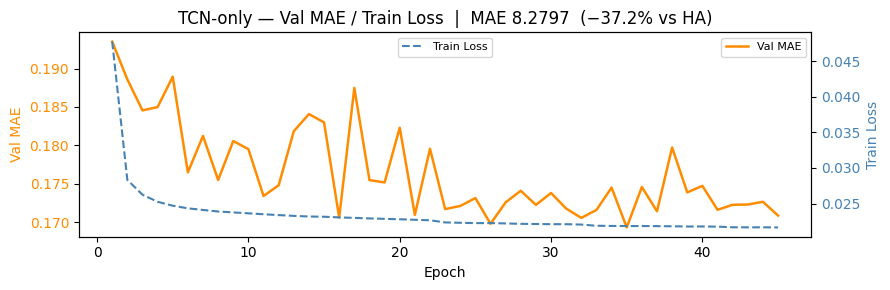

In [41]:
# TCN — Loss curve + improvement
fig, ax = plt.subplots(figsize=(9, 3))
ep = range(1, len(history_tcn) + 1)
ax2 = ax.twinx()
ax.plot(ep, [h[2] for h in history_tcn], color='darkorange', linewidth=1.8, label='Val MAE')
ax2.plot(ep, [h[0] for h in history_tcn], color='steelblue', linestyle='--', linewidth=1.5, label='Train Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MAE', color='darkorange')
ax2.set_ylabel('Train Loss', color='steelblue')
ax.tick_params(axis='y', labelcolor='darkorange')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax.legend(loc='upper right', fontsize=8); ax2.legend(loc='upper center', fontsize=8)
pct = (metrics_ha['MAE'] - metrics_tcn['MAE']) / metrics_ha['MAE'] * 100
ax.set_title(f'TCN-only — Val MAE / Train Loss  |  MAE {metrics_tcn["MAE"]:.4f}  (−{pct:.1f}% vs HA)')
plt.tight_layout(); plt.show()

## 9. STGNN — Asymmetric Log-Cosh Loss

In [44]:
torch.manual_seed(42); np.random.seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed(42)

stgnn_model   = STGNN(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW,
                      hidden_channels=32, tcn_channels=64,
                      use_transformer_decoder=True, decoder_layers=1).to(DEVICE)
stgnn_forward = lambda model, x_d, x_t: model(x_d, x_t, edge_index, edge_weight)
print(f'STGNN parameters: {sum(p.numel() for p in stgnn_model.parameters()):,}')

history_stgnn, stgnn_best_epoch = run_training(
    stgnn_model, train_loader, val_loader, stgnn_forward,
    loss_fn=asymmetric_log_cosh_loss, patience=20,
    save_path=f'{DATA_DIR}/stgnn_11_best.pth'
)

STGNN parameters: 470,529


Epoch   1 | train loss 0.0792 | train MAE 0.2795 | val MAE 0.2003 | val RMSE 0.2704 | best inf | patience 0/20 | lr 1.00e-03


Epoch   2 | train loss 0.0372 | train MAE 0.1857 | val MAE 0.1898 | val RMSE 0.2599 | best 0.2003 | patience 0/20 | lr 1.00e-03


Epoch   3 | train loss 0.0323 | train MAE 0.1718 | val MAE 0.1751 | val RMSE 0.2433 | best 0.1898 | patience 0/20 | lr 1.00e-03


Epoch   4 | train loss 0.0305 | train MAE 0.1662 | val MAE 0.1842 | val RMSE 0.2523 | best 0.1751 | patience 0/20 | lr 1.00e-03


...

Epoch  41 | train loss 0.0194 | train MAE 0.1316 | val MAE 0.1640 | val RMSE 0.2340 | best 0.1607 | patience 15/20 | lr 1.25e-04


Epoch  42 | train loss 0.0194 | train MAE 0.1315 | val MAE 0.1633 | val RMSE 0.2333 | best 0.1607 | patience 16/20 | lr 1.25e-04


Epoch  43 | train loss 0.0193 | train MAE 0.1314 | val MAE 0.1627 | val RMSE 0.2320 | best 0.1607 | patience 17/20 | lr 6.25e-05


Epoch  44 | train loss 0.0192 | train MAE 0.1311 | val MAE 0.1627 | val RMSE 0.2320 | best 0.1607 | patience 18/20 | lr 6.25e-05


Epoch  45 | train loss 0.0192 | train MAE 0.1310 | val MAE 0.1627 | val RMSE 0.2322 | best 0.1607 | patience 19/20 | lr 6.25e-05
→ Early stop @ epoch 45  (best epoch 25)


In [45]:
stgnn_model.load_state_dict(torch.load(f'{DATA_DIR}/stgnn_11_best.pth', map_location=DEVICE))
preds_stgnn, trues_stgnn = get_predictions(stgnn_model, test_loader, stgnn_forward)
metrics_stgnn = compute_metrics(trues_stgnn, preds_stgnn, scaler)
preds_r = features_mod.inverse_transform_demand(preds_stgnn, scaler)
trues_r = features_mod.inverse_transform_demand(trues_stgnn, scaler)
stgnn_peak, stgnn_offpeak = peak_offpeak_mae(preds_r, trues_r, hours_hod, split2)
print('STGNN:', {k: f"{v:.4f}" for k, v in metrics_stgnn.items()})
print(f'  Peak MAE: {stgnn_peak:.2f} | Off-peak MAE: {stgnn_offpeak:.2f} | Best epoch: {stgnn_best_epoch}')

STGNN: {'MAE': '8.1795', 'RMSE': '13.4184'}
  Peak MAE: 12.35 | Off-peak MAE: 6.79 | Best epoch: 25


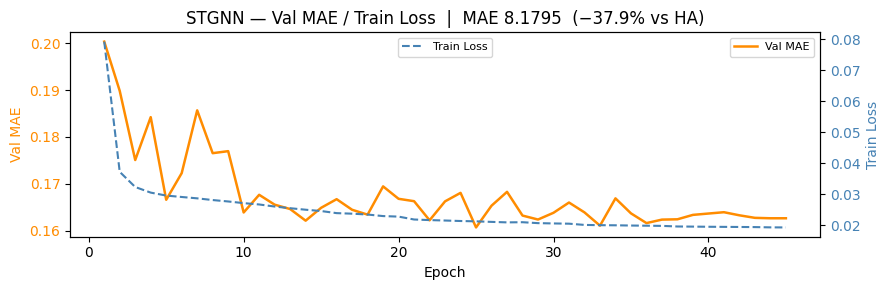

In [46]:
# STGNN — Loss curve + improvement
fig, ax = plt.subplots(figsize=(9, 3))
ep = range(1, len(history_stgnn) + 1)
ax2 = ax.twinx()
ax.plot(ep, [h[2] for h in history_stgnn], color='darkorange', linewidth=1.8, label='Val MAE')
ax2.plot(ep, [h[0] for h in history_stgnn], color='steelblue', linestyle='--', linewidth=1.5, label='Train Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MAE', color='darkorange')
ax2.set_ylabel('Train Loss', color='steelblue')
ax.tick_params(axis='y', labelcolor='darkorange')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax.legend(loc='upper right', fontsize=8); ax2.legend(loc='upper center', fontsize=8)
pct = (metrics_ha['MAE'] - metrics_stgnn['MAE']) / metrics_ha['MAE'] * 100
ax.set_title(f'STGNN — Val MAE / Train Loss  |  MAE {metrics_stgnn["MAE"]:.4f}  (−{pct:.1f}% vs HA)')
plt.tight_layout(); plt.show()

## 10. STGNN + Weather Asymmetric Log-Cosh Loss¶

In [ ]:
torch.manual_seed(42); np.random.seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed(42)

stgnn_w   = STGNN(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW,
                  hidden_channels=32, tcn_channels=64, weather_channels=9,
                  use_transformer_decoder=True, decoder_layers=1).to(DEVICE)
print(f'STGNN+Weather parameters: {sum(p.numel() for p in stgnn_w.parameters()):,}')

def train_epoch_w(model, loader, optimizer, loss_fn, epoch):
    model.train(); total = 0
    pbar = tqdm(loader, desc=f'Epoch {epoch:3d} [train]', leave=False)
    for x_d, x_t, x_w, y in pbar:
        x_d, x_t, x_w, y = x_d.to(DEVICE), x_t.to(DEVICE), x_w.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(x_d, x_t, edge_index, edge_weight, x_w), y.squeeze(-1))
        loss.backward(); optimizer.step(); total += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    return total / len(loader)

def eval_epoch_w(model, loader):
    model.eval(); mae_t = mse_t = 0
    pbar = tqdm(loader, desc='              [val]', leave=False)
    with torch.no_grad():
        for x_d, x_t, x_w, y in pbar:
            x_d, x_t, x_w, y = x_d.to(DEVICE), x_t.to(DEVICE), x_w.to(DEVICE), y.to(DEVICE)
            diff = model(x_d, x_t, edge_index, edge_weight, x_w) - y.squeeze(-1)
            mae_t += diff.abs().mean().item(); mse_t += (diff**2).mean().item()
            pbar.set_postfix({'val_mae': f'{mae_t / (pbar.n + 1):.4f}'})
    return mae_t/len(loader), (mse_t/len(loader))**0.5

opt_w     = torch.optim.Adam(stgnn_w.parameters(), lr=1e-3)
sched_w   = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_w, mode='min', factor=0.5, patience=5)
best_w, wait_w, hist_w, best_epoch_w = float('inf'), 0, [], 0
PATIENCE_W = 20

for ep in range(1, 101):
    tr = train_epoch_w(stgnn_w, train_w_loader, opt_w, asymmetric_log_cosh_loss, ep)
    va, vr = eval_epoch_w(stgnn_w, val_w_loader)
    hist_w.append((tr, va, vr))
    sched_w.step(va)
    lr_now = opt_w.param_groups[0]['lr']
    print(f'Epoch {ep:3d} | train {tr:.4f} | val MAE {va:.4f} | val RMSE {vr:.4f} | best {best_w:.4f} | patience {wait_w}/{PATIENCE_W} | lr {lr_now:.2e}')
    if va < best_w:
        best_w, wait_w, best_epoch_w = va, 0, ep
        torch.save(stgnn_w.state_dict(), f'{DATA_DIR}/stgnn_weather_11_best.pth')
    else:
        wait_w += 1
        if wait_w >= PATIENCE_W:
            print(f'→ Early stop @ epoch {ep}  (best epoch {best_epoch_w})')
            break

In [84]:
stgnn_w.load_state_dict(torch.load(f'{DATA_DIR}/stgnn_weather_11_best.pth', map_location=DEVICE))
stgnn_w.eval()
preds_sw, trues_sw = [], []
with torch.no_grad():
    for x_d, x_t, x_w, y in tqdm(test_w_loader, desc='Predicting', leave=False):
        preds_sw.append(stgnn_w(x_d.to(DEVICE), x_t.to(DEVICE), edge_index, edge_weight, x_w.to(DEVICE)).cpu().numpy())
        trues_sw.append(y.squeeze(-1).numpy())
preds_sw = np.concatenate(preds_sw)
trues_sw = np.concatenate(trues_sw)
metrics_stgnn_w = compute_metrics(trues_sw, preds_sw, scaler)
preds_sw_r = features_mod.inverse_transform_demand(preds_sw, scaler)
trues_sw_r = features_mod.inverse_transform_demand(trues_sw, scaler)
sw_peak, sw_offpeak = peak_offpeak_mae(preds_sw_r, trues_sw_r, hours_hod, split2)
print('STGNN+Weather:', {k: f"{v:.4f}" for k, v in metrics_stgnn_w.items()})
print(f'  Peak MAE: {sw_peak:.2f} | Off-peak MAE: {sw_offpeak:.2f} | Best epoch: {best_epoch_w}')

STGNN+Weather: {'MAE': '8.4872', 'RMSE': '14.0724'}
  Peak MAE: 13.28 | Off-peak MAE: 6.89 | Best epoch: 25


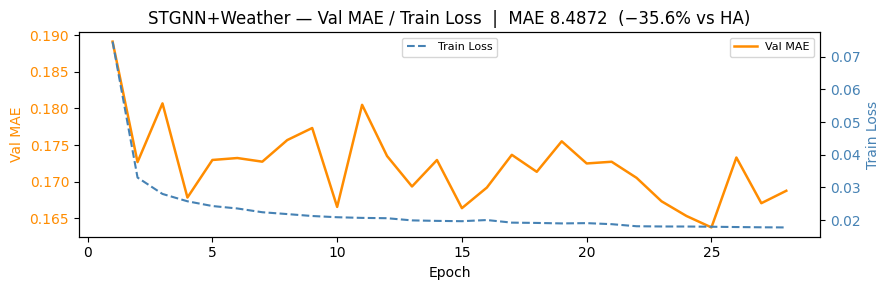

In [85]:
# STGNN+Weather — Loss curve + improvement
fig, ax = plt.subplots(figsize=(9, 3))
ep = range(1, len(hist_w) + 1)
ax2 = ax.twinx()
ax.plot(ep, [h[1] for h in hist_w], color='darkorange', linewidth=1.8, label='Val MAE')
ax2.plot(ep, [h[0] for h in hist_w], color='steelblue', linestyle='--', linewidth=1.5, label='Train Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MAE', color='darkorange')
ax2.set_ylabel('Train Loss', color='steelblue')
ax.tick_params(axis='y', labelcolor='darkorange')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax.legend(loc='upper right', fontsize=8); ax2.legend(loc='upper center', fontsize=8)
pct = (metrics_ha['MAE'] - metrics_stgnn_w['MAE']) / metrics_ha['MAE'] * 100
ax.set_title(f'STGNN+Weather — Val MAE / Train Loss  |  MAE {metrics_stgnn_w["MAE"]:.4f}  (−{pct:.1f}% vs HA)')
plt.tight_layout(); plt.show()

## 11. STGNN Symmetric Log-Cosh Loss¶

In [94]:
torch.manual_seed(42); np.random.seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed(42)

stgnn_sym = STGNN(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW,
                  hidden_channels=16, tcn_channels=64,
                  use_transformer_decoder=True, decoder_layers=1, dropout=0.3).to(DEVICE)
stgnn_sym_forward = lambda model, x_d, x_t: model(x_d, x_t, edge_index, edge_weight)
print(f'STGNN-sym parameters: {sum(p.numel() for p in stgnn_sym.parameters()):,}')

history_sym, sym_best_epoch = run_training(
    stgnn_sym, train_loader, val_loader, stgnn_sym_forward,
    loss_fn=log_cosh_loss, patience=20,
    save_path=f'{DATA_DIR}/stgnn_sym_11_best.pth'
)

STGNN-sym parameters: 447,297


Epoch   1 | train loss 0.0500 | train MAE 0.2485 | val MAE 0.1979 | val RMSE 0.2685 | best inf | patience 0/20 | lr 1.00e-03


Epoch   2 | train loss 0.0285 | train MAE 0.1831 | val MAE 0.1960 | val RMSE 0.2700 | best 0.1979 | patience 0/20 | lr 1.00e-03


Epoch   3 | train loss 0.0257 | train MAE 0.1735 | val MAE 0.1818 | val RMSE 0.2509 | best 0.1960 | patience 0/20 | lr 1.00e-03


Epoch   4 | train loss 0.0242 | train MAE 0.1681 | val MAE 0.1875 | val RMSE 0.2563 | best 0.1818 | patience 0/20 | lr 1.00e-03


...

Epoch  27 | train loss 0.0168 | train MAE 0.1385 | val MAE 0.1763 | val RMSE 0.2436 | best 0.1658 | patience 15/20 | lr 2.50e-04


Epoch  28 | train loss 0.0168 | train MAE 0.1383 | val MAE 0.1766 | val RMSE 0.2442 | best 0.1658 | patience 16/20 | lr 2.50e-04


Epoch  29 | train loss 0.0167 | train MAE 0.1379 | val MAE 0.1717 | val RMSE 0.2389 | best 0.1658 | patience 17/20 | lr 1.25e-04


Epoch  30 | train loss 0.0165 | train MAE 0.1370 | val MAE 0.1708 | val RMSE 0.2383 | best 0.1658 | patience 18/20 | lr 1.25e-04


Epoch  31 | train loss 0.0164 | train MAE 0.1368 | val MAE 0.1738 | val RMSE 0.2418 | best 0.1658 | patience 19/20 | lr 1.25e-04
→ Early stop @ epoch 31  (best epoch 11)


In [95]:
stgnn_sym.load_state_dict(torch.load(f'{DATA_DIR}/stgnn_sym_11_best.pth', map_location=DEVICE))
preds_sym, trues_sym = get_predictions(stgnn_sym, test_loader, stgnn_sym_forward)
metrics_sym = compute_metrics(trues_sym, preds_sym, scaler)
preds_sym_r = features_mod.inverse_transform_demand(preds_sym, scaler)
trues_sym_r = features_mod.inverse_transform_demand(trues_sym, scaler)
sym_peak, sym_offpeak = peak_offpeak_mae(preds_sym_r, trues_sym_r, hours_hod, split2)
print('STGNN-sym:', {k: f"{v:.4f}" for k, v in metrics_sym.items()})
print(f'  Peak MAE: {sym_peak:.2f} | Off-peak MAE: {sym_offpeak:.2f} | Best epoch: {sym_best_epoch}')

STGNN-sym: {'MAE': '8.3200', 'RMSE': '13.4516'}
  Peak MAE: 12.41 | Off-peak MAE: 6.96 | Best epoch: 11


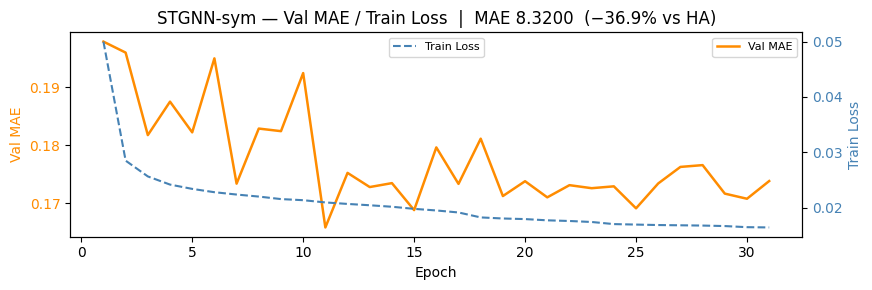

In [96]:
fig, ax = plt.subplots(figsize=(9, 3))
ep = range(1, len(history_sym) + 1)
ax2 = ax.twinx()
ax.plot(ep, [h[2] for h in history_sym], color='darkorange', linewidth=1.8, label='Val MAE')
ax2.plot(ep, [h[0] for h in history_sym], color='steelblue', linestyle='--', linewidth=1.5, label='Train Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MAE', color='darkorange')
ax2.set_ylabel('Train Loss', color='steelblue')
ax.tick_params(axis='y', labelcolor='darkorange')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax.legend(loc='upper right', fontsize=8); ax2.legend(loc='upper center', fontsize=8)
pct = (metrics_ha['MAE'] - metrics_sym['MAE']) / metrics_ha['MAE'] * 100
ax.set_title(f'STGNN-sym — Val MAE / Train Loss  |  MAE {metrics_sym["MAE"]:.4f}  (−{pct:.1f}% vs HA)')
plt.tight_layout(); plt.show()

## 12 STGNN (07)

In [100]:
torch.manual_seed(42); np.random.seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed(42)

stgnn_sym = STGNN(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW,
                  hidden_channels=32, tcn_channels=64,
                  use_transformer_decoder=True).to(DEVICE)
stgnn_sym_forward = lambda model, x_d, x_t: model(x_d, x_t, edge_index, edge_weight)
print(f'STGNN-sym parameters: {sum(p.numel() for p in stgnn_sym.parameters()):,}')

history_sym, sym_best_epoch = run_training(
    stgnn_sym, train_loader, val_loader, stgnn_sym_forward,
    loss_fn=log_cosh_loss, patience=20,
    save_path=f'{DATA_DIR}/stgnn_sym_11_best.pth'
)

STGNN-sym parameters: 669,313


Epoch   1 | train loss 0.0751 | train MAE 0.3212 | val MAE 0.2105 | val RMSE 0.2815 | best inf | patience 0/20 | lr 1.00e-03


Epoch   2 | train loss 0.0294 | train MAE 0.1873 | val MAE 0.1825 | val RMSE 0.2496 | best 0.2105 | patience 0/20 | lr 1.00e-03


Epoch   3 | train loss 0.0248 | train MAE 0.1706 | val MAE 0.1880 | val RMSE 0.2580 | best 0.1825 | patience 0/20 | lr 1.00e-03


Epoch   4 | train loss 0.0234 | train MAE 0.1652 | val MAE 0.1718 | val RMSE 0.2405 | best 0.1825 | patience 1/20 | lr 1.00e-03


...

Epoch  37 | train loss 0.0134 | train MAE 0.1242 | val MAE 0.1658 | val RMSE 0.2346 | best 0.1621 | patience 15/20 | lr 1.25e-04


Epoch  38 | train loss 0.0133 | train MAE 0.1240 | val MAE 0.1653 | val RMSE 0.2329 | best 0.1621 | patience 16/20 | lr 1.25e-04


Epoch  39 | train loss 0.0133 | train MAE 0.1239 | val MAE 0.1655 | val RMSE 0.2347 | best 0.1621 | patience 17/20 | lr 6.25e-05


Epoch  40 | train loss 0.0132 | train MAE 0.1236 | val MAE 0.1657 | val RMSE 0.2350 | best 0.1621 | patience 18/20 | lr 6.25e-05


Epoch  41 | train loss 0.0132 | train MAE 0.1235 | val MAE 0.1674 | val RMSE 0.2374 | best 0.1621 | patience 19/20 | lr 6.25e-05
→ Early stop @ epoch 41  (best epoch 21)


In [101]:
stgnn_sym.load_state_dict(torch.load(f'{DATA_DIR}/stgnn_sym_11_best.pth', map_location=DEVICE))
preds_sym, trues_sym = get_predictions(stgnn_sym, test_loader, stgnn_sym_forward)
metrics_sym = compute_metrics(trues_sym, preds_sym, scaler)
preds_sym_r = features_mod.inverse_transform_demand(preds_sym, scaler)
trues_sym_r = features_mod.inverse_transform_demand(trues_sym, scaler)
sym_peak, sym_offpeak = peak_offpeak_mae(preds_sym_r, trues_sym_r, hours_hod, split2)
print('STGNN-sym:', {k: f"{v:.4f}" for k, v in metrics_sym.items()})
print(f'  Peak MAE: {sym_peak:.2f} | Off-peak MAE: {sym_offpeak:.2f} | Best epoch: {sym_best_epoch}')


STGNN-sym: {'MAE': '8.2017', 'RMSE': '13.6871'}
  Peak MAE: 12.36 | Off-peak MAE: 6.81 | Best epoch: 21


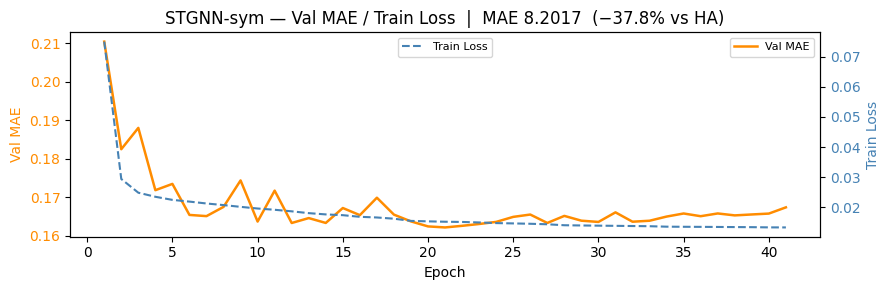

In [102]:
fig, ax = plt.subplots(figsize=(9, 3))
ep = range(1, len(history_sym) + 1)
ax2 = ax.twinx()
ax.plot(ep, [h[2] for h in history_sym], color='darkorange', linewidth=1.8, label='Val MAE')
ax2.plot(ep, [h[0] for h in history_sym], color='steelblue', linestyle='--', linewidth=1.5, label='Train Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MAE', color='darkorange')
ax2.set_ylabel('Train Loss', color='steelblue')
ax.tick_params(axis='y', labelcolor='darkorange')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax.legend(loc='upper right', fontsize=8); ax2.legend(loc='upper center', fontsize=8)
pct = (metrics_ha['MAE'] - metrics_sym['MAE']) / metrics_ha['MAE'] * 100
ax.set_title(f'STGNN-sym — Val MAE / Train Loss  |  MAE {metrics_sym["MAE"]:.4f}  (−{pct:.1f}% vs HA)')
plt.tight_layout(); plt.show()


## 11. Results Summary

In [103]:
ha_mae = metrics_ha['MAE']

summary = pd.DataFrame([
    {'Model': 'Historical Average', 'Loss': '—',                    'MAE': metrics_ha['MAE'],      'RMSE': metrics_ha['RMSE'],      'Peak MAE': '—',                     'Off-peak MAE': '—',                       'Best Epoch': '—',              'ΔvHA': '—'},
    {'Model': 'LSTM',               'Loss': 'log-cosh',             'MAE': metrics_lstm['MAE'],    'RMSE': metrics_lstm['RMSE'],    'Peak MAE': round(lstm_peak, 2),     'Off-peak MAE': round(lstm_offpeak, 2),    'Best Epoch': lstm_best_epoch,  'ΔvHA': f"−{(ha_mae - metrics_lstm['MAE']) / ha_mae * 100:.1f}%"},
    {'Model': 'TCN-only',           'Loss': 'log-cosh',             'MAE': metrics_tcn['MAE'],     'RMSE': metrics_tcn['RMSE'],     'Peak MAE': round(tcn_peak, 2),      'Off-peak MAE': round(tcn_offpeak, 2),     'Best Epoch': tcn_best_epoch,   'ΔvHA': f"−{(ha_mae - metrics_tcn['MAE']) / ha_mae * 100:.1f}%"},
    {'Model': 'STGNN (asym)',       'Loss': 'asym log-cosh (α=2)',  'MAE': metrics_stgnn['MAE'],   'RMSE': metrics_stgnn['RMSE'],   'Peak MAE': round(stgnn_peak, 2),    'Off-peak MAE': round(stgnn_offpeak, 2),   'Best Epoch': stgnn_best_epoch, 'ΔvHA': f"−{(ha_mae - metrics_stgnn['MAE']) / ha_mae * 100:.1f}%"},
    {'Model': 'STGNN (sym)',        'Loss': 'log-cosh',             'MAE': metrics_sym['MAE'],     'RMSE': metrics_sym['RMSE'],     'Peak MAE': round(sym_peak, 2),      'Off-peak MAE': round(sym_offpeak, 2),     'Best Epoch': sym_best_epoch,   'ΔvHA': f"−{(ha_mae - metrics_sym['MAE']) / ha_mae * 100:.1f}%"},
    {'Model': 'STGNN+Weather',      'Loss': 'asym log-cosh (α=2)',  'MAE': metrics_stgnn_w['MAE'],'RMSE': metrics_stgnn_w['RMSE'], 'Peak MAE': round(sw_peak, 2),       'Off-peak MAE': round(sw_offpeak, 2),      'Best Epoch': best_epoch_w,     'ΔvHA': f"−{(ha_mae - metrics_stgnn_w['MAE']) / ha_mae * 100:.1f}%"},
]).set_index('Model')

print(summary.to_string())
summary

                                   Loss        MAE       RMSE Peak MAE Off-peak MAE Best Epoch    ΔvHA
Model                                                                                                 
Historical Average                    —  13.179804  21.199223        —            —          —       —
LSTM                           log-cosh   8.024109  13.085569    12.58         6.51         34  −39.1%
TCN-only                       log-cosh   8.279655  13.839990    12.83         6.76         35  −37.2%
STGNN (asym)        asym log-cosh (α=2)   8.179531  13.418370    12.35         6.79         25  −37.9%
STGNN (sym)                    log-cosh   8.201731  13.687104    12.36         6.81         21  −37.8%
STGNN+Weather       asym log-cosh (α=2)   8.487201  14.072403    13.28         6.89         25  −35.6%


,Loss,MAE,RMSE,Peak MAE,Off-peak MAE,Best Epoch,ΔvHA
Model,,,,,,,
Historical Average,—,13.179804,21.199223,—,—,—,—
LSTM,log-cosh,8.024109,13.085569,12.58,6.51,34,−39.1%
TCN-only,log-cosh,8.279655,13.839990,12.83,6.76,35,−37.2%
STGNN (asym),asym log-cosh (α=2),8.179531,13.418370,12.35,6.79,25,−37.9%
STGNN (sym),log-cosh,8.201731,13.687104,12.36,6.81,21,−37.8%
STGNN+Weather,asym log-cosh (α=2),8.487201,14.072403,13.28,6.89,25,−35.6%


## 12. Forecast Visualization

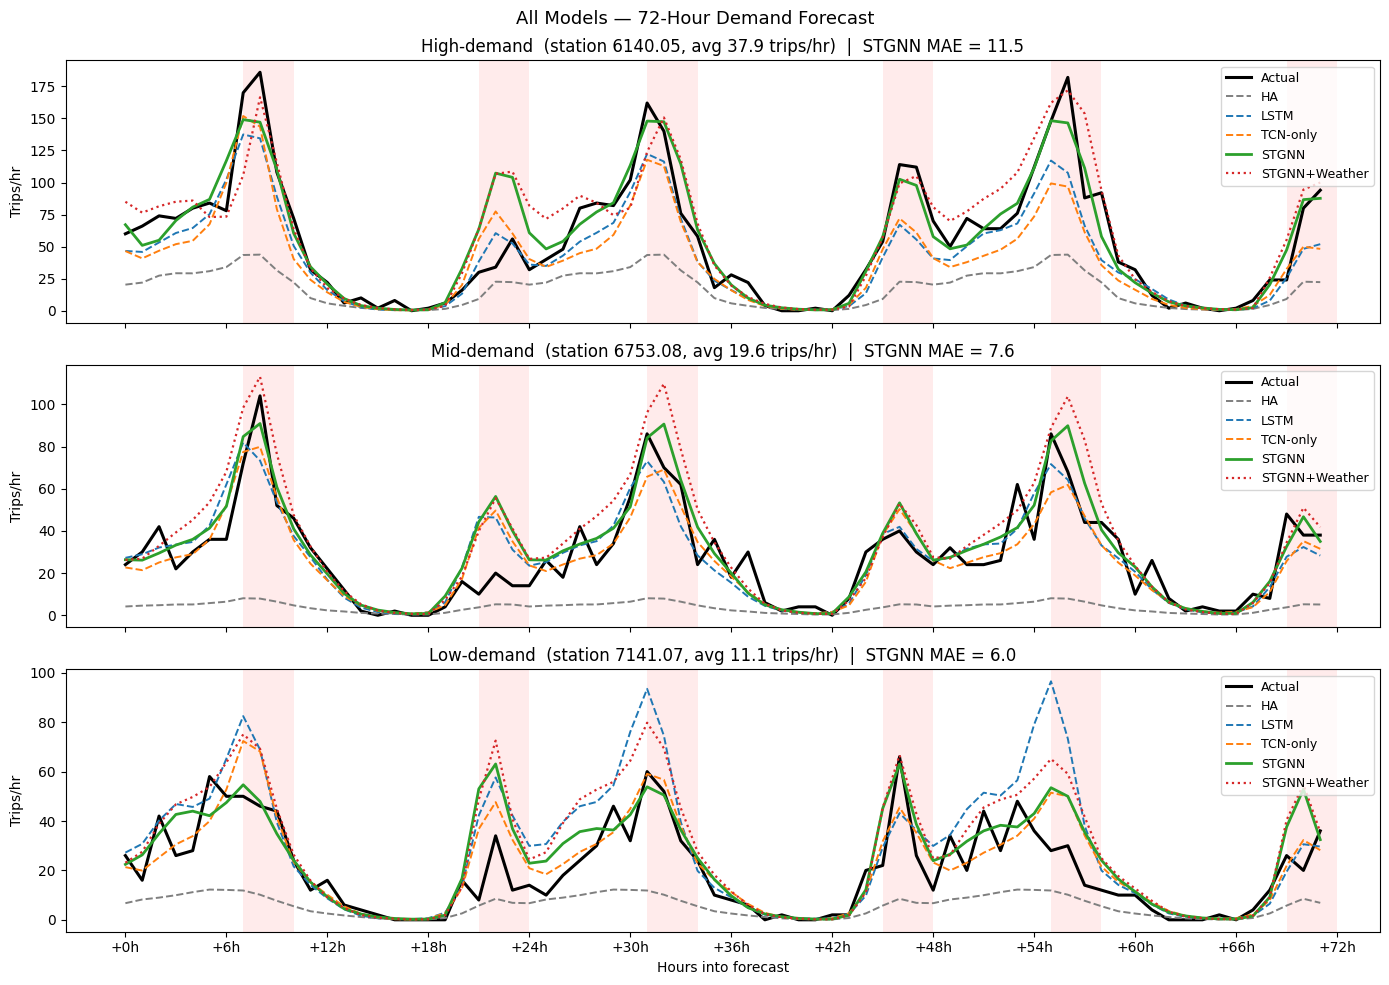

In [107]:
# All-model comparison — high / mid / low demand stations
test_mean  = test_demand.mean(axis=0)
high_idx = int(test_mean.argsort()[-1])
mid_idx  = int(test_mean.argsort()[-50])
low_idx  = int(test_mean.argsort()[5])
sample_idx = 300

preds_ha_r = features_mod.inverse_transform_demand(y_pred_ha.transpose(0, 2, 1), scaler)

model_lines = [
    ('Actual',        trues_r,      'black',   '-',  2.2),
    ('HA',            preds_ha_r,   '#7f7f7f', '--', 1.4),
    ('LSTM',          preds_lstm_r, '#1f77b4', '--', 1.4),
    ('TCN-only',      preds_tcn_r,  '#ff7f0e', '--', 1.4),
    ('STGNN',         preds_r,      '#2ca02c', '-',  2.0),
    ('STGNN+Weather', preds_sw_r,   '#d62728', ':',  1.6),
]

peak_hods  = {7, 8, 9, 17, 18, 19}
start_hod  = int(hours_hod[split2 + INPUT_WINDOW + sample_idx])
peak_steps = [t for t in range(OUTPUT_WINDOW) if (start_hod + t) % 24 in peak_hods]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, s_idx, label in zip(axes,
    [high_idx, mid_idx, low_idx],
    ['High-demand', 'Mid-demand', 'Low-demand']):

    for t in peak_steps:
        ax.axvspan(t, t + 1, alpha=0.08, color='red', linewidth=0)

    for name, arr, color, ls, lw in model_lines:
        ax.plot(arr[sample_idx, s_idx], color=color, linestyle=ls,
                linewidth=lw, label=name)

    mae_s = np.abs(preds_r[:, s_idx, :] - trues_r[:, s_idx, :]).mean()
    ax.set_ylabel('Trips/hr')
    ax.set_title(
        f'{label}  (station {station_ids[s_idx]}, '
        f'avg {test_mean[s_idx]:.1f} trips/hr)  |  STGNN MAE = {mae_s:.1f}'
    )
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xticks(range(0, OUTPUT_WINDOW + 1, 6))
axes[-1].set_xticklabels([f'+{h}h' for h in range(0, OUTPUT_WINDOW + 1, 6)])
axes[-1].set_xlabel('Hours into forecast')
plt.suptitle('All Models — 72-Hour Demand Forecast', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/all_models_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Error Analysis

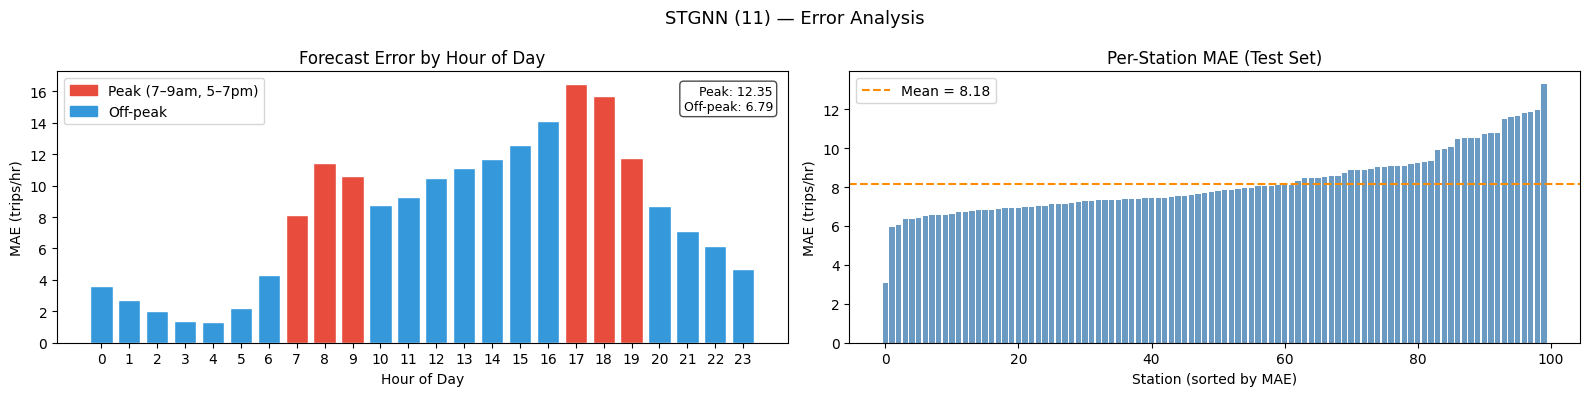

Peak hour MAE:    12.35 trips/hr
Off-peak MAE:     6.79 trips/hr
Best 5 stations:  ['6266.06', '7141.07', '6432.11', '6955.05', '6925.09']
Worst 5 stations: ['6331.01', '6948.10', '6876.04', '6492.08', '6364.07']


In [108]:
n_samples = preds_r.shape[0]
i_idx     = np.arange(n_samples)[:, None]
t_idx     = np.arange(OUTPUT_WINDOW)[None, :]
step_hod  = hours_hod[split2 + INPUT_WINDOW + i_idx + t_idx]
err_step  = np.abs(preds_r - trues_r).mean(axis=1)
hourly_mae = np.array([err_step[step_hod == h].mean() for h in range(24)])

peak   = [7, 8, 9, 17, 18, 19]
colors = ['#e74c3c' if h in peak else '#3498db' for h in range(24)]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
ax.bar(range(24), hourly_mae, color=colors, edgecolor='white')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('MAE (trips/hr)')
ax.set_title('Forecast Error by Hour of Day'); ax.set_xticks(range(24))
ax.text(0.98, 0.95, f'Peak: {stgnn_peak:.2f}\nOff-peak: {stgnn_offpeak:.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.legend(handles=[Patch(color='#e74c3c', label='Peak (7–9am, 5–7pm)'),
                   Patch(color='#3498db', label='Off-peak')], loc='upper left')

ax2 = axes[1]
station_mae_arr = np.abs(preds_r - trues_r).mean(axis=(0, 2))
sorted_idx = station_mae_arr.argsort()
ax2.bar(range(100), station_mae_arr[sorted_idx], color='steelblue', alpha=0.8)
ax2.axhline(station_mae_arr.mean(), color='darkorange', linestyle='--', linewidth=1.5,
            label=f'Mean = {station_mae_arr.mean():.2f}')
ax2.set_xlabel('Station (sorted by MAE)'); ax2.set_ylabel('MAE (trips/hr)')
ax2.set_title('Per-Station MAE (Test Set)'); ax2.legend()

plt.suptitle('STGNN (11) — Error Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Peak hour MAE:    {stgnn_peak:.2f} trips/hr')
print(f'Off-peak MAE:     {stgnn_offpeak:.2f} trips/hr')
print(f'Best 5 stations:  {[station_ids[i] for i in sorted_idx[:5]]}')
print(f'Worst 5 stations: {[station_ids[i] for i in sorted_idx[-5:]]}')